<br>

## 1. Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score




<br>

## 2. Load Datasets & Set up

Load the ML-ready dataset and separate feature and target columns for modeling.

This dataset is already preprocessed, encoded, and scaled, making it suitable for direct use in machine learning models.

In [ ]:
# Load datasets
df = pd.read_pickle('../Data/processed_data/ml_ready_data.pkl')
features_df = pd.read_pickle('../Data/processed_data/features_columns.pkl')
target_df = pd.read_pickle('../Data/processed_data/target_columns.pkl')

# Preview dataset
df.head()

In [ ]:
# Extract column names
features_columns = features_df.columns
target_columns = target_df.columns

# Preview features and targets
df[features_columns].head()
df[target_columns].head()

<br>

## 3. Check Label Imbalace

We compute:
- Imbalance ratio
- Coefficient of variation (CV)

These metrics quantify the degree of imbalance in the label distribution.

In [ ]:
# Calculate label frequency
label_counts=df[target_columns].sum().sort_values(ascending=False)

# Imbalance Ratio: max frequency / min frequency
imbalance_ratio = label_counts.max() / label_counts.min()
print('Imbalace Ration = ',imbalance_ratio)

# Coefficient of Variation (CV): std / mean
cv = label_counts.std()/label_counts.mean()
print('Coefficient of Variation = ',cv)

# Plot label distribution
label_counts.plot(kind='bar',figsize=(12,5))
plt.title('Distribution of Label')

### Observations

- The label distribution is highly imbalanced.
- The imbalance ratio (~70.7) indicates a significant gap between the most frequent and least frequent job roles.
- The coefficient of variation (~1.26) confirms a high level of variability across label frequencies.

- A small number of roles dominate the dataset:
  - `Back-end`, `Full-stack` have the highest frequencies (above 17,500).

  - `Front-end`, `Desktop`, and `Mobile` roles are also common but significantly less dominant.

- Several roles such as `Marketing` and `Senior Executive/VP` have very low representation.

- Aside from these extremes, most roles fall within a moderate range (approximately 1,000–2,500), showing relative balance among mid-frequency classes.

<br>

### Impact on Modeling
- The dataset exhibits strong class imbalance, which can bias the model toward dominant roles.
- Accuracy is not an appropriate evaluation metric, as it would be misleading in this context.
- Evaluation should focus on:
  - **F1-score (micro)** for overall performance
  - **F1-score (macro)** to assess performance on rare roles

- Rare job roles require careful evaluation due to their low representation.

- This imbalance should be considered when selecting modeling strategies and during hyperparameter tuning.

<br>

## 4. Check Features Dependacy
Analyze dependencies and multicollinearity between feature variables (skills) using two complementary approaches:

1. Correlation coefficient heatmap
2. Variance Inflation Factor (VIF)

This step helps assess whether features are highly correlated, which may impact model selection and interpretation.

In [ ]:
# 1. Correlation coefficient heatmap

# Compute correlation matrix for feature columns
corr_matrix = df[features_columns].corr()

# Visualize correlation matrix using a heatmap style
corr_matrix.style.background_gradient(cmap='coolwarm').set_precision(2)

In [ ]:
# 2. Variance Inflation Factor (VIF)

# Initialize dataframe to store VIF results
vif_data = pd.DataFrame()

# Store feature names
vif_data["feature"] = features_columns

# Compute VIF for each feature
vif_data["VIF"] = [
    variance_inflation_factor(df[features_columns].values, i)
    for i in range(len(df[features_columns].columns))
    ]

# Sort features by VIF in descending order
# Higher VIF → stronger multicollinearity
vif_data=vif_data.sort_values(by=["VIF"],ascending=False)

vif_data



### Observations

- Overall, feature correlations between skills are generally low, indicating that most technologies are relatively independent.
- A few moderate correlations exist between related technologies, such as:
  - "Hadoop" , 'Apache Spark'  (0.44)
  - "C" , "C++"  (0.49)
  - "Flutter" , "Dart"  (0.58)

- Higher correlations are observed within the .NET ecosystem:
  - ".NET" , ".NET Core" (0.72)
  - "ASP.NET Core" , ".NET Core" (0.79)
  - "C#" , (".NET" / ".NET Core") (~0.70+)
  - "ASP.NET" , (".NET Core" / "ASP.NET Core") (0.57–0.68)

- VIF results confirm the same pattern:
  - All features have relatively low multicollinearity (VIF < 5)
  - The highest VIF values are within the .NET-related features (≈ 2.5–4.0)

- Observed dependencies mainly reflect technological relationships between tools rather than redundancy.

<br>

---
<br>

### Impact on Modeling

- The assumption of feature independence is largely reasonable for most models, including Naive Bayes.
- Localized dependencies exist within technology families (especially the .NET ecosystem), which may:
  - Slightly violate independence assumptions in probabilistic models
  - Introduce redundancy in linear models

- Tree-based models are less affected by these dependencies, while linear models (e.g., Logistic Regression) may benefit from regularization.

<br>

---
<br>

### Plan

To address structured dependencies while preserving information:

1. Create a higher-level aggregated feature:
   - `.NET_ecosystem` → combining all .NET-related technologies

2. Evaluate multiple feature representations:
   - Original feature set
   - Reduced feature set (with `.NET_ecosystem`)
   - Combined feature set (both original + aggregated)

3. Apply regularization in linear models to reduce impact of correlated features.

4. Compare all feature strategies using cross-validation to determine the most effective representation for modeling performance.

In [ ]:
# Create aggregated feature representing the .NET ecosystem

# Since features were previously standardized,
#  we use (> 0) to recover original binary meaning:
df['.NET_ecosystem'] = (
    (df['.NET'] > 0) |
    (df['.NET Core'] > 0) |
    (df['ASP.NET'] > 0) |
    (df['ASP.NET Core'] > 0)
).astype(int)


# Standardize the new feature to maintain consistency with other features
# This ensures all features are on the same scale for modeling
df['.NET_ecosystem'] = zscore(df['.NET_ecosystem'])

# Add the new feature to the list of feature columns
features_columns = features_columns.append(pd.Index(['.NET_ecosystem']))


# Preview updated feature set including the new column
df[features_columns]

## 4. Model & Feature Set Evaluation

### Objective

Evaluate multiple machine learning models across different feature sets to identify the most effective feature representation.

<br>


### Approach
- We evaluate each feature set using multiple models from different learning families:
  - Logistic Regression (linear model)
  - Linear SVM (margin-based model)
  - Random Forest (tree-based model)
  - Naive Bayes (probabilistic model)

  Using multiple models ensures that the selected feature set performs well       **independently of a specific algorithm**, making it more robust and generalizable.


- Models such as Decision Trees and KNN were excluded because:
    - Decision Trees tend to overfit on high-dimensional sparse data
    - KNN performs poorly in high-dimensional spaces (curse of dimensionality)


- We use **5-fold Cross-Validation** to ensure robust and stable performance estimates
- The evaluation metric is **F1-micro**, which:
  - Handles class imbalance effectively
  - Aggregates performance across all labels
  - Is well-suited for multi-label classification problems


In [ ]:
# Extract input features (X) and target labels (y)
X = df[features_columns]
y = df[target_columns]

# Split dataset into training and testing sets
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2
)

In [ ]:
# Define Feature Set Variations
# We evaluate three different feature configurations
X_sets = {
    "original": X_train.drop(columns=['.NET_ecosystem']),
    "dotNET_only": X_train.drop(columns=['.NET', '.NET Core', 'ASP.NET', 'ASP.NET Core']),
    "combined": X_train
}



# Define Models
models = {
    'lr': OneVsRestClassifier(LogisticRegression(max_iter=1000)),
    'rf': RandomForestClassifier(),
    'svc': OneVsRestClassifier(LinearSVC()),
    'nb': OneVsRestClassifier(GaussianNB())
}

In [ ]:
# Cross-Validation Evaluation Loop

results=[]

for X_name,X in X_sets.items():
    for model_name, model in models.items():
        scores = cross_val_score(model, X, y_train, cv=5, scoring='f1_micro')
        score=scores.mean()
        results.append({
            'model': model_name,
            'feature_set': X_name,
            'score': score
        })

results_df = pd.DataFrame(results)
results_df.sort_values(by="score", ascending=False)
results_df

c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the

,model,feature_set,score
0,lr,original,0.507492
1,rf,original,0.491439
2,svc,original,0.493197
3,nb,original,0.388474
4,lr,dotNET_only,0.505298
5,rf,dotNET_only,0.489809
6,svc,dotNET_only,0.490557
7,nb,dotNET_only,0.387091
8,lr,combined,0.507822
9,rf,combined,0.492770


In [ ]:
# Reshape results into a pivot table for easier comparison
results_pivot_df = results_df.pivot(index='model', columns='feature_set', values='score')
results_pivot_df

feature_set,combined,dotNET_only,original
model,,,
lr,0.507822,0.505298,0.507492
nb,0.387422,0.387091,0.388474
rf,0.492770,0.489809,0.491439
svc,0.493545,0.490557,0.493197


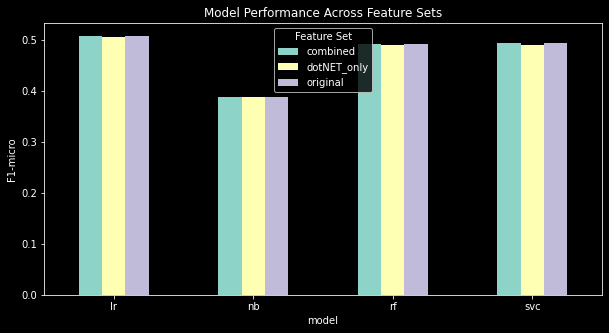

In [ ]:
# Plot bar chart to visually compare model performance across feature sets
results_pivot_df.plot(kind='bar', figsize=(10,5))
plt.ylabel("F1-micro")
plt.title("Model Performance Across Feature Sets")
plt.xticks(rotation=0)
plt.legend(title="Feature Set")

### Observations

- Logistic Regression achieves the best performance across all feature sets, followed  by Linear SVM.
- Random Forest shows lower performance compared to linear models
- Naive Bayes performed significantly worse, likely due to its strong independence assumptions.

- The differences between feature sets are minimal:
  - The **combined** feature set performs slightly better overall.
  - The **original** feature set is very close in performance.
  - The **dotNET_only** feature set shows a small decrease in performance.

---

### Conclusion

- Feature engineering using `.NET_ecosystem` provides a **minor improvement**, but does not significantly change model performance.

- Linear models (Logistic Regression and Linear SVM) are more suitable for this dataset than tree-based or probabilistic models.

---

### Plan

- The **combined feature set** is selected for the next stage
- Focus on the following models:
  - Logistic Regression
  - Linear SVM
  - Random Forest (as a secondary comparison)
- Move to the next stage for model selection and tuning.